In [26]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
from scipy.optimize import fsolve
import numpy as np

In [27]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is not available


In [28]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-5, atol=1.0e-3):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()
        state0 = torch.zeros(
            forces.shape[1:-1] + (self.discrete_equations.nstate,), device=forces.device
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[...,0:1]

In [30]:
nchunk = 50
nmodel = neml2.load_model("new_model_test.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_X", "E_Y", "elasticity_nu", "C_X", "g_X", "athermal_L", "athermal_b", "flow_rate_b", "rho_m_rate_L", "shear_athermal_m", "shear_eff_m",
                                                                            "sy_X", "v_disl_Bk", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_pierls_stress", "G_X", "G_Y", "v_disl_p", "v_disl_q", "k1_X", "k2_X",
                                                                            "athermal_alpha", "v_disl_T_ref", "v_disl_Bk", "v_disl_k_B", "v_disl_activation_energy", "T_0_X", "T_ref_X"]))

Name:       implicit_rate
Input:      forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: athermal_L [Scalar][Double][cpu]
            athermal_alpha [Scalar][Double][cpu]
            athermal_b [Scalar][Double][cpu]
            athermal_shear_modulus [Scalar][Double][cpu]
            elasticity_E [Scalar][Double][cpu]
            elasticity_nu [Scalar][Double]

In [31]:
nbatch = 1
ntime = 100
max_strain = 0.4
rate = 1e-4
temp = 873.15 #K (600C)
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

time_values = torch.linspace(0.0, max_strain / rate, ntime, device=device)
strain_values = torch.linspace(0.0, max_strain, ntime, device=device)

time[:,:,0] = time_values.unsqueeze(1)
loading[:,:,0] = strain_values.unsqueeze(1)
temperature[:,:,0] = temp

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")



--- Full Input Tensors ---
time: torch.Size([100, 1, 1])
temperature: torch.Size([100, 1, 1])
loading: torch.Size([100, 1, 6])


In [32]:
with torch.no_grad():
    stress = model(time, temperature, loading)

Text(0, 0.5, 'Stress [MPa]')

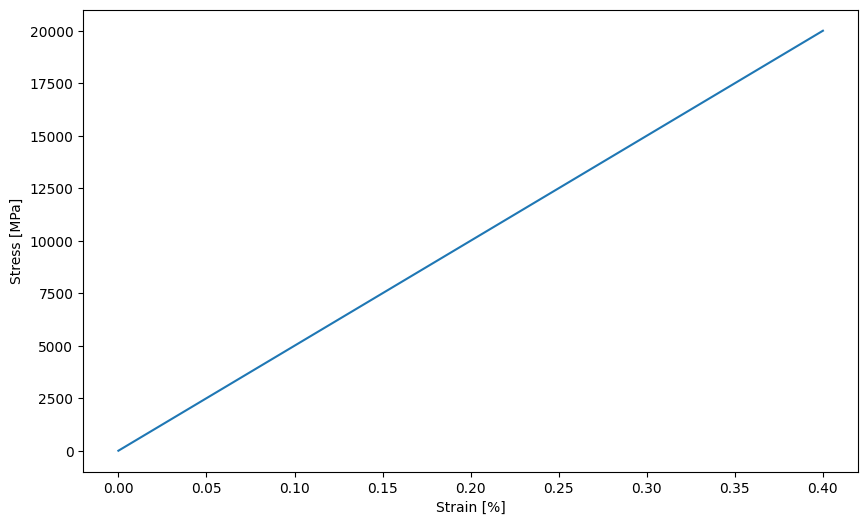

In [33]:
plt.figure(figsize=(10,6))
plt.plot(loading[...,0].cpu().numpy(), stress[...,0].cpu().numpy())
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')